In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Create the value object
* it will have operations like add, mul
* it will store data, link to previous nodes, operation for this node and grad value which is gradient of this node

In [3]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [4]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
a + b
a.__add__(b)

Value(data=-1.0)

In [5]:
c = Value(10.0, label='c')
d = a*b + c
d


Value(data=4.0)

In [6]:
print(d._prev)
print(d._op)

{Value(data=10.0), Value(data=-6.0)}
+


In [7]:
e = a*b; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Value(data=-8.0)

In [8]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    # dot.node(name = uid, label = "{ %s | data %.4f }" % (n.label, n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

ModuleNotFoundError: No module named 'graphviz'

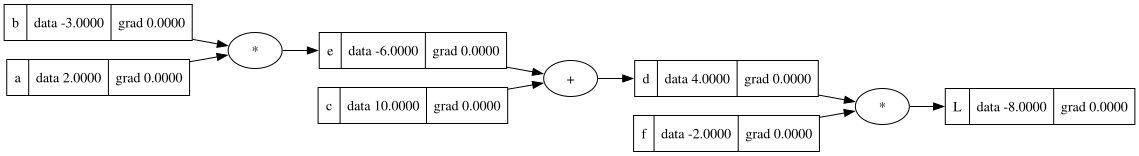

In [ ]:
draw_dot(L)

In [9]:
L.grad = 1.0

In [10]:
h = 0.001

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L1 = L.data

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L2 = L.data

print((L2 - L1)/h)

0.0


chaging `f` by h and calculating gradient DL/df

In [11]:
d = e + c ; d.label = 'd'
# d.data += h
f = Value(-2.0 + h, label='f')
L = d*f; L.label = 'L'
L2 = L.data

print((L2 - L1)/h)

3.9999999999995595


In [12]:
f.grad = 4.0

chaging `d` by h and calculating gradient DL/dd

In [13]:
d = e + c ; d.label = 'd'
d.data += h
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L2 = L.data

print((L2 - L1)/h)

-2.000000000000668


In [14]:
d.grad = -2.0

printing the graph

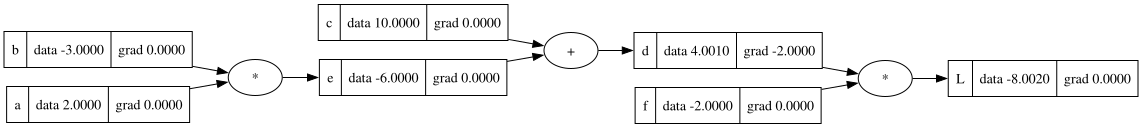

In [ ]:
draw_dot(L)

calculating derivative of c, e

dd/dc = ?

d = c + e
using, (f(x + h) - f(x))/h
dd/dc => ((c+h + e) - (c + e))/h
      => (c + h + e - c - e)/h
      => h/h = 1.0

similarly, for dd/de
    = 1.0


by chain rule,
dL/dc = (dL/dd) * (dd/dc)
=> DL/dc = -2.0 * 1.0 = -2.0
=> DL/de = -2.0

In [16]:
c.grad = -2.0
e.grad = -2.0

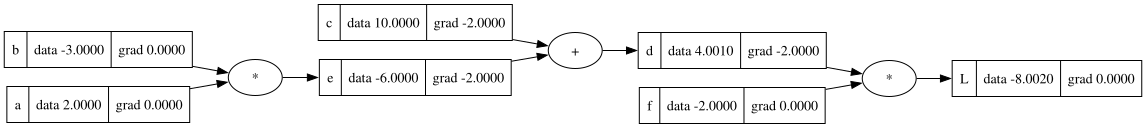

In [ ]:
draw_dot(L)

In [18]:
h = 0.001

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L1 = L.data

a = Value(2.0, label='a')
b = Value(-3.0, label='b')

# incrementing c + h
c = Value(10.0 + h, label='c')
e = a*b; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L2 = L.data

print((L2 - L1)/h)

c = Value(10.0, label='c')
e = a*b; e.label = 'e'
e.data += h
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L2 = L.data

print((L2 - L1)/h)

-1.9999999999988916
-2.000000000000668


calculating derivative of a, b

e = a * b
de/da = b (as we have calculated earlier)

by chain rule,
dL/da = dL/de * de/da
=> -2.0 * -3.0

dL/db = DL/de * de/db
=> -2.0 * 2.0

In [19]:
a.grad = -2.0 * -3.0
b.grad =  -2.0 * 2.0

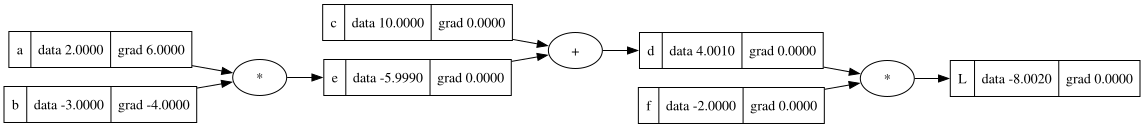

In [ ]:
draw_dot(L)

In [21]:
# verifying this

a = Value(2.0 + h, label='a')
b = Value(-3.0, label='b')

c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L2 = L.data

print((L2 - L1)/h)

a = Value(2.0, label='a')
b = Value(-3.0 + h, label='b')

c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L2 = L.data

print((L2 - L1)/h)

6.000000000000227
-3.9999999999995595


In [22]:
# setting all grad values

f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = -2.0 * -3.0
b.grad =  -2.0 * 2.0

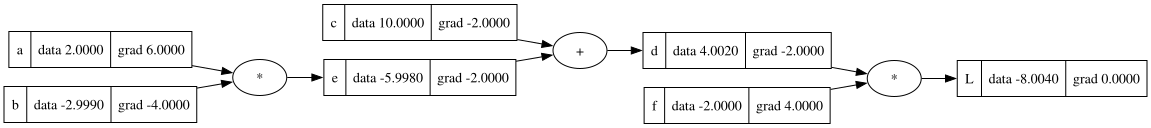

In [ ]:
draw_dot(L)

In [24]:
# if we nudge values in direction of grad, we should nudge L up

print(L.data)

h = 0.01
a.data += h * a.grad
b.grad += h * b.grad
c.grad += h * c.grad
f.grad += h * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-8.004
-7.644119999999999


backpropagation though a neuron

![neuron structure](assets/neuron_model.jpg)

f -> activation function like tanh or sigmoid

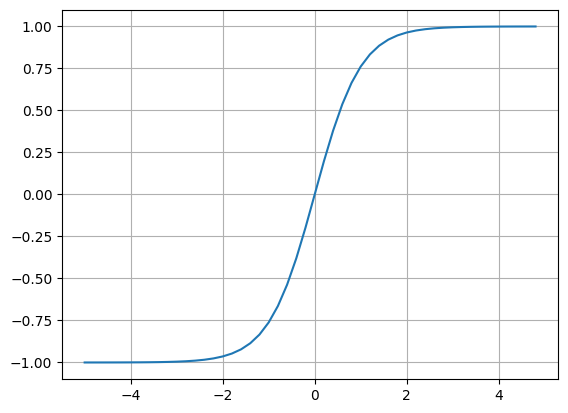

In [ ]:
# numpy tanh function
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

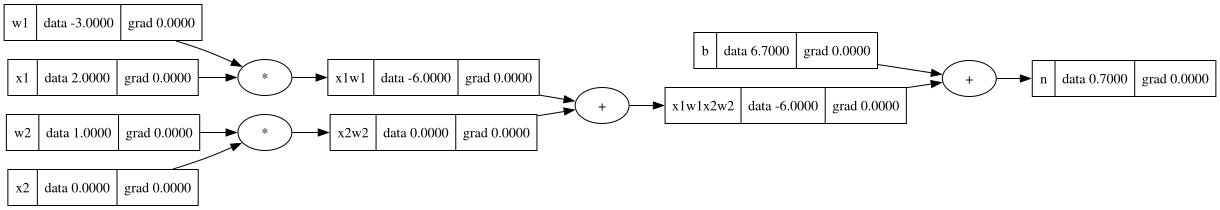

In [ ]:
# inputs x1, x2 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias if the neuron
b = Value(6.7, label='b')

#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

draw_dot(n)

In [27]:
# define tanh funtion for Value
def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')
    return out

Value.tanh = tanh

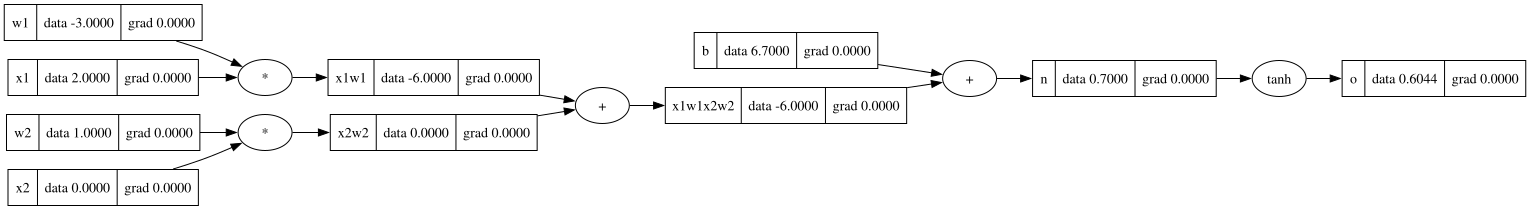

In [ ]:
o = n.tanh(); o.label = 'o'

draw_dot(o)

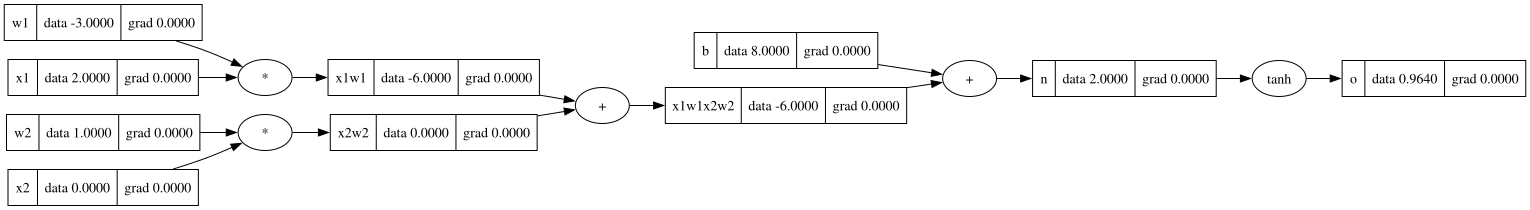

In [ ]:
# increasing bias
b = Value(8, label='b')

# x1w1 + x2w2 + b (here just updating for changed b)
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

draw_dot(o)

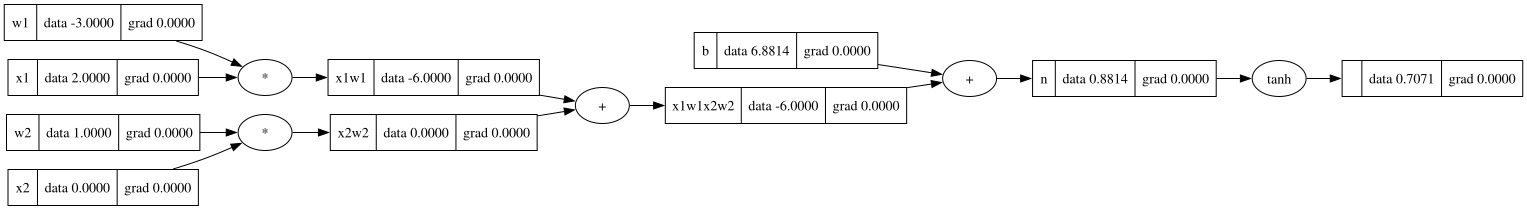

In [ ]:
# increasing bias
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b (here just updating for changed b)
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh()

draw_dot(o)

In [31]:
o.grad = 1.0

o = tanh(n)

do/dn = ?

from derivatives, d(tanhx)/dx = 1 - tanh^2(x) = sech^2(x) = 1/cosh^2(x)

so, do/dn = 1- tanh^2 (n)
we know, tanh(n) = o
=> do/dn, 1 - o^2 = (1- o^2)


In [32]:
n.grad = o.data**2

In [33]:
# + (plus) operation results in flow (distribution) of gradient from previous example
# that is, n.grad = 0.5
x1w1x2w2.grad = 0.5
b.grad = 0.5

# same for next + operation
x1w1.grad = 0.5
x2w2.grad = 0.5

In [34]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

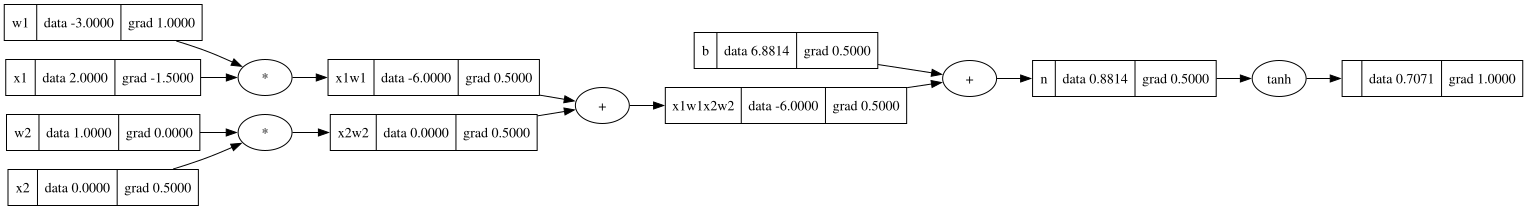

In [ ]:
draw_dot(o)

Lets start automating backpropagation

In [36]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        # add backward function
        self._backward = lambda: None

    def __repr__(self) -> str:
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        # to accept other as int as well as Value
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        # to accept other as int as well as Value
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out
    
    # with __mul__ Value * int works but int * Value does not. this swaps so, int * Value becomes Value * int
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other): # self/other
        return self * other**-1
    
    def __pow__(self, other): # self^other
        assert isinstance(other, (int, float)) # for now support int and float
        out = Value(self.data**other, (self,), f'**{other}')
    
        def _backward():
            self.grad = other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out
    
    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        other.data = -other.data
        
        return self + (other.data)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1) 
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad = out.data * out.grad
        
        out._backward = _backward
        return out



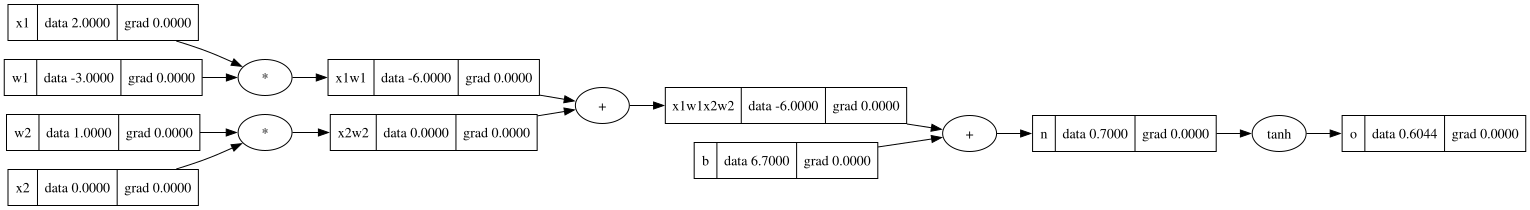

In [ ]:
# inputs x1, x2 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias if the neuron
b = Value(6.7, label='b')

#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)

In [38]:
o.grad = 1.0
o._backward()

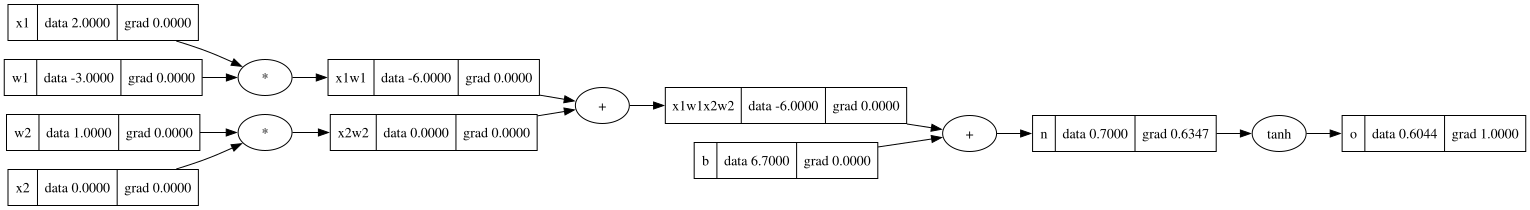

In [ ]:
draw_dot(o)

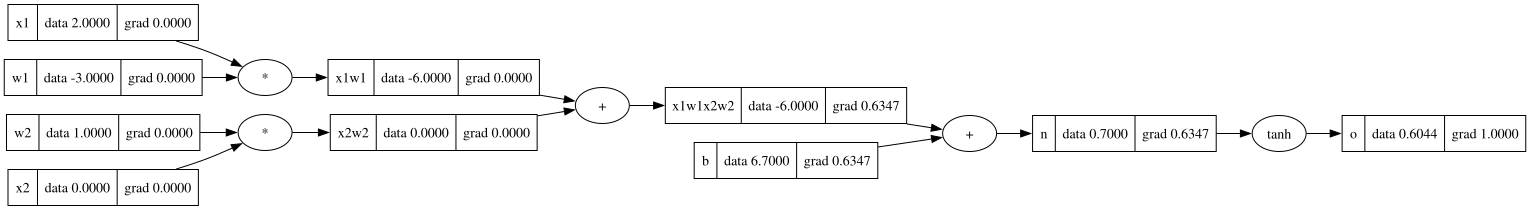

In [ ]:
n._backward()
draw_dot(o)

In [41]:
# instead of calling backward, we can see auto call _backward() in topological short order

def backward(self):

    # topological order all of the children in the graph
    topo = []
    visited = set()
    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)
    build_topo(self)

    # go one variable at a time and apply the chain rule to get its gradient
    self.grad = 1
    for v in reversed(topo):
        v._backward()

Value.backward = backward

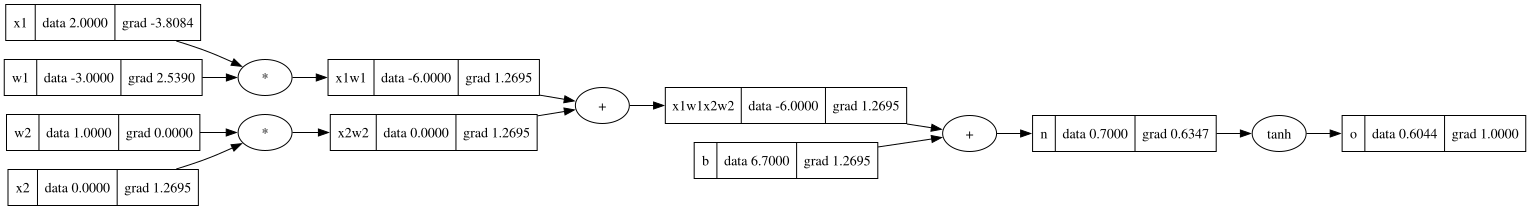

In [ ]:
# now, calling backward() should compute grad for all nodes processed

o.backward()
draw_dot(o)

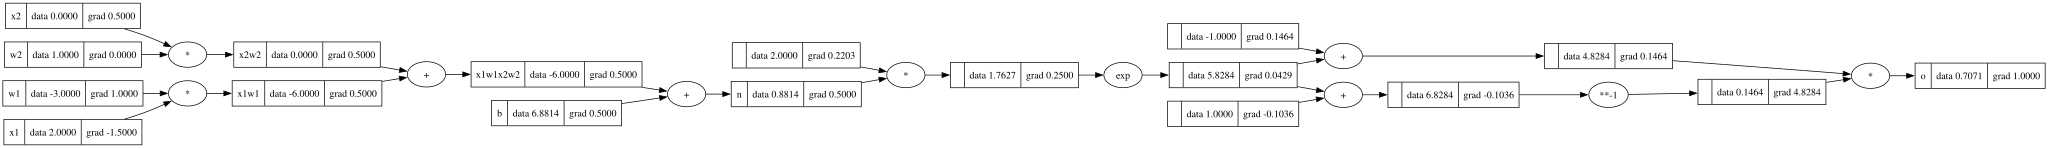

In [ ]:
# inputs x1, x2 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias if the neuron
b = Value(6.8813735870195432, label='b')

#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# ------------

# o = n.tanh(); o.label = 'o'
# tanh(x) = e^2x - 1/e^2x + 1
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'

# -----------

o.backward()

draw_dot(o)

Lets do the same thing using python

In [ ]:
import torch

x1 = torch.Tensor([2.0]).double();             x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();             x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();             w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();             w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double()
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())

o.backward()

print('------------')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())



ModuleNotFoundError: No module named 'torch'

this is exactly equal to the values of grad in our graph above so Pytorch agrees with our calculation and its correct!